# Notebook 02 — Alineamiento Múltiple de Secuencias (MSA) y Mapa Posicional

**Notebook:** `02_alignment_mapping.ipynb`  
**TFM:** Bioinformática estructural — Familia RAS  
**Objetivo:** Alineamiento multiple de KRAS, HRAS y NRAS, construcción del mapa de equivalencias posicion-a-posicion e identificación de posiciones recurrentemente mutadas.

---

## Que es un Alineamiento Multiple de Secuencias (MSA)?

Un **alineamiento mútiple de secuencias** (Multiple Sequence Alignment, MSA) es una disposicion de tres o más secuencias biológicas (proteínas o ácidos nucleicos) en columnas, de modo que cada columna agrupa residuos que comparten **origen evolutivo** u ocupan el **mismo lugar en la estructura 3D**.

Los algoritmos de MSA introducen **gaps** (`-`) en las secuencias cuando una de ellas presenta una inserción o deleción respecto a las demás, asegurandose de que los residuos homólogos queden alineados verticalmente. La calidad del alineamiento se mide mediante funciones de puntuación basadas en matrices de sustitución (como BLOSUM62 para proteínas) y penalizaciones por gaps.

---

## Por qué alineamos KRAS, HRAS y NRAS?

Las tres isoformas de la familia RAS son **genes parálogos**: surgieron por duplicación del mismo gen ancestral durante la evolución de los vertebrados. Sus dominios catalíticos G comparten una identidad de secuencia superior al 85 %, lo que significa que más de 8 de cada 10 posiciones tienen exactamente el mismo aminoácido.

Sin embargo, existen **diferencias puntuales** que pueden:

- Alterar la velocidad intrínseca de hidrólisis del GTP.
- Modificar la afinidad por distintos efectores (RAF, PI3K, RalGDS).
- Determinar la localización subcelular a traves de la region hipervariable C-terminal.

Para comparar correctamente las mutaciones oncogénicas entre isoformas (por ejemplo, saber si "KRAS G12" y "NRAS G12" son la **misma posicion estructural**) necesitamos un MSA que establezca un **mapa de equivalencias** posición-a-posición.

---

## Que informacion obtenemos?

De este notebook extraemos tres artefactos clave:

| Artefacto | Fichero de salida | Descripción |
|-----------|------------------|-------------|
| MSA en formato FASTA | `data/processed/msa_ras.fasta` | Las tres secuencias alineadas con gaps |
| Mapa posicional | `data/processed/position_map.csv` | Tabla de equivalencias columna por columna |
| Posiciones recurrentes | `data/processed/recurrent_positions.csv` | Hotspots mutados en 2 o más isoformas |
| Figura del MSA | `figures/02_msa_overview.png` | Visualización coloreada del alineamiento |

---

## Prerequisitos

Este notebook **requiere** que el notebook 01 haya sido ejecutado previamente y haya generado:

- `data/processed/cosmic_curated.csv` (dataset de mutaciones curadas de COSMIC)

## Controles obligatorios
Los hotspots G12, G13 y Q61 deben poder localizarse en los tres miembros de RAS.

---
## Sección 1: Importaciones y configuración de rutas

En esta primera celda cargamos todas las bibliotecas necesarias y configuramos las rutas del proyecto. 

In [1]:
# ============================================================
# CHUNK 1.1: Importaciones y configuración general
# ============================================================

import warnings                   
from pathlib import Path           

import pandas as pd               
from Bio import AlignIO            

# Importaciones del paquete propio del TFM
from tfm_ras.config import load_config, project_root   
from tfm_ras.alignment import (                        
    fetch_uniprot_sequence,        
    run_msa,                       
    build_position_map,            
    find_recurrent_positions,     
    visualize_msa,                 
    identity_fraction,             
    consensus_sequence,            
)

print("[OK] Bibliotecas importadas correctamente.")

[OK] Bibliotecas importadas correctamente.


In [2]:
# ============================================================
# CHUNK 1.2: Configuracion de rutas absolutas del proyecto
# ============================================================

# project_root() devuelve un objeto Path con la ruta absoluta a la raiz del proyecto.
ROOT = project_root()

# Directorio con los ficheros FASTA de las secuencias canonicas descargadas de UniProt
SEQ_DIR = ROOT / "data" / "external" / "sequences"

# Directorio de datos procesados donde se guardan los resultados intermedios del pipeline
PROCESSED_DIR = ROOT / "data" / "processed"

# Directorio de figuras del proyecto
FIGURES_DIR = ROOT / "figures"

# Ruta del fichero CSV curado generado por el notebook 01 (prerequisito obligatorio)
COSMIC_CURATED_PATH = PROCESSED_DIR / "cosmic_curated.csv"

# Ruta de salida para el MSA en formato FASTA
MSA_OUTPUT_PATH = PROCESSED_DIR / "msa_ras.fasta"

# Ruta de salida para el mapa posicional en formato CSV
POSITION_MAP_PATH = PROCESSED_DIR / "position_map.csv"

# Ruta de salida para la tabla de posiciones recurrentes
RECURRENT_PATH = PROCESSED_DIR / "recurrent_positions.csv"

# Ruta de salida para la figura del MSA
FIGURE_MSA_PATH = FIGURES_DIR / "02_msa_overview.png"

# Crear los directorios de salida si no existen
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"[OK] Raiz del proyecto : {ROOT}")
print(f"[OK] Directorio de secuencias : {SEQ_DIR}")
print(f"[OK] Directorio de resultados : {PROCESSED_DIR}")

[OK] Raiz del proyecto : /Users/rachi/Desktop/TFM/tfm_ras_mutations
[OK] Directorio de secuencias : /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/external/sequences
[OK] Directorio de resultados : /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed


In [3]:
# ============================================================
# CHUNK 1.3: Opciones de visualizacion de pandas
# ============================================================

# pd.set_option() permite configurar el comportamiento de visualizacion de pandas.
# Estos ajustes son globales para toda la sesion del notebook.

# display.max_rows: numero maximo de filas que se muestran al imprimir un DataFrame.
pd.set_option("display.max_rows", 50)

# display.max_columns: None significa que se muestran todas las columnas sin truncar.
pd.set_option("display.max_columns", None)

# display.width: ancho maximo en caracteres para la representacion del DataFrame.
pd.set_option("display.width", 120)

# display.float_format: formato para mostrar numeros de punto flotante.
pd.set_option("display.float_format", "{:.4f}".format)

print("[OK] Opciones de visualizacion de pandas configuradas.")

[OK] Opciones de visualizacion de pandas configuradas.


---
## Sección 2: Carga de la configuracion y del dataset curado

La configuracion del proyecto (`configs/config.yaml`) centraliza todos los parámetros del análisis: identificadores UniProt de las tres isoformas, umbrales de frecuencia para considerar una posición como recurrente, coordenadas de las regiones funcionales, etc.

El dataset curado (`data/processed/cosmic_curated.csv`) contiene las mutaciones missense somáticas confirmadas para KRAS, HRAS y NRAS, con columnas normalizadas.

In [4]:
# ============================================================
# CHUNK 2.1: Cargar la configuracion YAML del proyecto
# ============================================================

CFG = load_config(ROOT / 'configs' / 'config.yaml')

# Extraemos los identificadores UniProt de cada isoforma RAS desde la configuracion.
uniprot_ids = {
    gene: info["uniprot_id"]
    for gene, info in CFG["family"]["members"].items()
}

# Extraemos los umbrales de recurrencia definidos en la configuracion.
MIN_MEMBERS = CFG["thresholds"]["recurrent_min_members"]
MIN_SAMPLES = CFG["thresholds"]["recurrent_min_samples_per_member"]

# Extraemos los hotspots oncogénicos clave definidos en la configuracion.
hotspots_cfg = CFG["hotspots"]

print("[OK] Configuracion cargada.")
print(f"  Isoformas          : {uniprot_ids}")
print(f"  Umbral min_members : {MIN_MEMBERS}")
print(f"  Umbral min_samples : {MIN_SAMPLES}")
print(f"  Hotspots           : {hotspots_cfg}")

[OK] Configuracion cargada.
  Isoformas          : {'KRAS': 'P01116', 'HRAS': 'P01112', 'NRAS': 'P01111'}
  Umbral min_members : 2
  Umbral min_samples : 10
  Hotspots           : [{'position': 12, 'residue': 'G'}, {'position': 13, 'residue': 'G'}, {'position': 61, 'residue': 'Q'}, {'position': 146, 'residue': 'A'}, {'position': 117, 'residue': 'K'}, {'position': 59, 'residue': 'A'}]


In [5]:
# ============================================================
# CHUNK 2.2: Verificar y cargar el dataset curado del Hito 1
# ============================================================

# Verificamos que el fichero curado existe antes de intentar cargarlo.
if not COSMIC_CURATED_PATH.is_file():
    raise FileNotFoundError(
        f"No se encontro el fichero curado: {COSMIC_CURATED_PATH}\n"
        "Ejecuta primero el notebook 01 para generarlo."
    )

# pd.read_csv() carga el fichero CSV en un DataFrame de pandas.
curated = pd.read_csv(COSMIC_CURATED_PATH)

# Mostrar un resumen del dataset cargado para confirmar su estructura.
print(f"[OK] Dataset curado cargado desde: {COSMIC_CURATED_PATH}")
print(f"  Filas      : {len(curated):,}")
print(f"  Columnas   : {list(curated.columns)}")
print()

# Mostrar la distribucion de mutaciones por gen usando value_counts().
print("Mutaciones únicas por gen:")
print(curated["gene"].value_counts().to_string())

[OK] Dataset curado cargado desde: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/cosmic_curated.csv
  Filas      : 469
  Columnas   : ['gene', 'uniprot_id', 'position', 'wt_aa', 'mut_aa', 'hgvs_p', 'sample_count', 'tumor_types', 'primary_tissues', 'cosmic_version']

Mutaciones únicas por gen:
gene
KRAS    207
NRAS    133
HRAS    129


In [6]:
# ============================================================
# CHUNK 2.3: Inspeccion visual de las primeras filas del dataset
# ============================================================

# Devuelve las primeras 5 filas del DataFrame por gen.
display(curated.groupby('gene').head(5))

,gene,uniprot_id,position,wt_aa,mut_aa,hgvs_p,sample_count,tumor_types,primary_tissues,cosmic_version
0,KRAS,P01116,12,G,D,p.G12D,4697,Ewing_sarcoma-peripheral_primitive_neuroectode...,NS | autonomic_ganglia | biliary_tract | bone ...,v104
1,KRAS,P01116,12,G,V,p.G12V,3625,Wilms_tumour | aberrant_crypt_foci | adenoma |...,NS | autonomic_ganglia | biliary_tract | breas...,v104
2,KRAS,P01116,13,G,D,p.G13D,1716,NS | aberrant_crypt_foci | adenoma | angiosarc...,NS | biliary_tract | breast | cervix | endomet...,v104
3,KRAS,P01116,12,G,C,p.G12C,1345,aberrant_crypt_foci | adenoma | angiosarcoma |...,NS | biliary_tract | breast | cervix | endomet...,v104
4,KRAS,P01116,12,G,A,p.G12A,728,aberrant_crypt_foci | adenoma | carcinoid-endo...,NS | autonomic_ganglia | biliary_tract | breas...,v104
207,HRAS,P01112,13,G,R,p.G13R,240,adnexal_tumour | benign_melanocytic_nevus | ca...,adrenal_gland | autonomic_ganglia | breast | l...,v104
208,HRAS,P01112,61,Q,R,p.Q61R,214,angiosarcoma | benign_melanocytic_nevus | carc...,adrenal_gland | autonomic_ganglia | breast | g...,v104
209,HRAS,P01112,61,Q,K,p.Q61K,84,adenoma-nodule-goitre | carcinoma | germ_cell_...,adrenal_gland | autonomic_ganglia | bone | bre...,v104
210,HRAS,P01112,12,G,S,p.G12S,64,carcinoma | malignant_melanoma | other | rhabd...,bone | endometrium | large_intestine | oesopha...,v104
211,HRAS,P01112,61,Q,L,p.Q61L,64,angiosarcoma | benign_melanocytic_nevus | carc...,breast | central_nervous_system | liver | lung...,v104


---
## Sección 3: Descarga y carga de secuencias canónicas desde UniProt

Las secuencias canónicas de las proteínas RAS provienen de **UniProt** (Universal Protein Resource, https://www.uniprot.org), la base de datos de referencia para secuencias y anotaciones de proteínas. Cada isoforma tiene un identificador de acceso único:

| Gen | UniProt ID | Longitud (aa) |
|-----|-----------|---------------|
| KRAS | P01116 | 189 |
| HRAS | P01112 | 189 |
| NRAS | P01111 | 189 |

La función `fetch_uniprot_sequence()` implementa una estrategia de **cache local**: si el fichero FASTA ya existe en `data/external/sequences/`, lo lee del disco sin hacer ninguna peticion de red. Esto hace que las siguientes ejecuciones del notebook sean instantáneas y no dependan de disponibilidad de internet.

El formato **FASTA** es el estándar para representar secuencias biológicas. Cada entrada consiste en:
- Una linea de cabecera que empieza por `>` con el identificador y descripción.
- Una o más líneas con la secuencia de aminoácidos en código de una letra.

La función devuelve directamente la secuencia como cadena de texto (sin cabecera), lista para usar en el alineamiento.

In [7]:
# ============================================================
# CHUNK 3.1: Descargar o cargar desde cache las secuencias UniProt
# ============================================================

# Construimos el diccionario de secuencias {nombre_gen -> secuencia_aminoacidos}.
# Las claves DEBEN ser exactamente "KRAS", "HRAS", "NRAS" para que run_msa()
# reconozca las tres isoformas y use el camino optimizado sin herramienta externa.
sequences = {
    gene: fetch_uniprot_sequence(uniprot_id)
    for gene, uniprot_id in uniprot_ids.items()
}

print("[OK] Secuencias cargadas:")
for gene, seq in sequences.items():
    # Mostramos los primeros 40 residuos como verificacion visual rapida.
    # Todos deben comenzar por 'M' (metionina inicial) si son secuencias canónicas.
    print(f"  {gene}: {len(seq)} aa | primeros 40: {seq[:40]}")

[OK] Secuencias cargadas:
  KRAS: 189 aa | primeros 40: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY
  HRAS: 189 aa | primeros 40: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY
  NRAS: 189 aa | primeros 40: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY


In [8]:
# ============================================================
# CHUNK 3.2: Verificacion de longitudes y residuos clave
# ============================================================

# Verificar que las tres secuencias tienen la misma longitud (189 aminoácidos).
lengths = {gene: len(seq) for gene, seq in sequences.items()}
print("Longitudes de secuencia:")
for gene, length in lengths.items():
    print(f"  {gene}: {length} aa")

if len(set(lengths.values())) == 1:
    print("\n[OK] Las tres secuencias tienen la misma longitud -> alineamiento sin gaps.")
else:
    print("\n[WARN] Las secuencias tienen longitudes distintas -> se necesitara herramienta externa.")

print()

# Verificar los hotspots clave en la secuencia de KRAS.
kras_seq = sequences["KRAS"]
print("Verificacion de hotspots en KRAS:")
for hs in hotspots_cfg:
    pos = hs["position"]          
    expected_aa = hs["residue"]  
    observed_aa = kras_seq[pos - 1]  
    status = "[OK]" if observed_aa == expected_aa else "[FAIL]"
    print(f"  {status} Posicion {pos}: esperado '{expected_aa}', observado '{observed_aa}'")

Longitudes de secuencia:
  KRAS: 189 aa
  HRAS: 189 aa
  NRAS: 189 aa

[OK] Las tres secuencias tienen la misma longitud -> alineamiento sin gaps.

Verificacion de hotspots en KRAS:
  [OK] Posicion 12: esperado 'G', observado 'G'
  [OK] Posicion 13: esperado 'G', observado 'G'
  [OK] Posicion 61: esperado 'Q', observado 'Q'
  [OK] Posicion 146: esperado 'A', observado 'A'
  [OK] Posicion 117: esperado 'K', observado 'K'
  [OK] Posicion 59: esperado 'A', observado 'A'


---
## Sección 4: Ejecución del alineamiento múltiple de secuencias (MSA)

### Que algoritmo se usa y por qué?

La función `run_msa()` soporta tres herramientas de MSA: **ClustalOmega** (`clustalo`), **MAFFT** y **MUSCLE**. Por defecto usa ClustalOmega, que es la opción mas robusta para proteínas con alta identidad de secuencia.

**ClustalOmega** es el sucesor moderno de ClustalW. Utiliza:
1. **Perfiles HMM** (Hidden Markov Models) para representar la distribución estadística de aminoácidos en cada posición.
2. **Árboles guía** construidos con algoritmos de agrupamiento jerárquico (neighbor-joining) para determinar el orden de alineamiento progresivo.
3. Matrices de distancias basadas en $k$-tuplas para una estimación rápida de similitud entre secuencias.

Para el caso particular de KRAS, HRAS y NRAS, si las tres secuencias tienen **exactamente la misma longitud** (189 residuos), `run_msa()` utiliza un camino optimizado que construye directamente el alineamiento **sin gaps**, sin necesidad de invocar ninguna herramienta externa. Esto es biológicamente correcto: las tres isoformas tienen la misma longitud en su dominio catalítico G y los residuos homólogos se corresponden posición a posición.

El modulo emitira una advertencia informativa indicando que se usa el alineamiento sin gaps. Esto es **el comportamiento esperado** y no indica ningun error.

In [9]:
# ============================================================
# CHUNK 4.1: Ejecutar el alineamiento multiple de secuencias
# ============================================================

# run_msa() acepta un diccionario {nombre_gen -> secuencia} y el nombre del algoritmo.
# Devuelve un objeto Bio.Align.MultipleSeqAlignment (BioPython) con el alineamiento.

with warnings.catch_warnings(record=True) as captured_warnings:
    warnings.simplefilter("always")

    # Ejecutar el alineamiento con el algoritmo por defecto (ClustalOmega).
    msa = run_msa(sequences, algorithm="clustalo")

if captured_warnings:
    for w in captured_warnings:
        print(f"[INFO] Aviso del modulo de alineamiento: {w.message}")

print()
print(f"[OK] MSA generado correctamente.")
print(f"  Tipo del objeto       : {type(msa).__name__}")
print(f"  Numero de secuencias  : {len(msa)}")
print(f"  Longitud del MSA      : {msa.get_alignment_length()} columnas")

[INFO] Aviso del modulo de alineamiento: Secuencias KRAS/HRAS/NRAS de igual longitud; usando alineamiento sin gaps.

[OK] MSA generado correctamente.
  Tipo del objeto       : MultipleSeqAlignment
  Numero de secuencias  : 3
  Longitud del MSA      : 189 columnas


In [10]:
# ============================================================
# CHUNK 4.2: Inspección básica del objeto MSA de BioPython
# ============================================================

# Mostrar cada registro del alineamiento.
# Un objeto MultipleSeqAlignment de BioPython es iterable: cada elemento es un SeqRecord.
# SeqRecord tiene atributos .id (identificador), .seq (secuencia) y .description.
print("Registros del alineamiento:")
print("-" * 85)
for record in msa:
    seq_str = str(record.seq)

    n_gaps = seq_str.count("-")

    # Mostrar el identificador, los primeros 40 residuos y el numero de gaps.
    print(f"  ID: {record.id:<8}  | primeros 40: {seq_str[:40]}  | gaps: {n_gaps}")

print("-" * 85)

Registros del alineamiento:
-------------------------------------------------------------------------------------
  ID: KRAS      | primeros 40: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY  | gaps: 0
  ID: HRAS      | primeros 40: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY  | gaps: 0
  ID: NRAS      | primeros 40: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY  | gaps: 0
-------------------------------------------------------------------------------------


---
## Sección 5: Estadísticas del MSA

Una vez obtenido el alineamiento, calculamos tres estadísticas fundamentales:

1. **Longitud del MSA**: número total de columnas del alineamiento, incluyendo posiciones con gaps. Para KRAS/HRAS/NRAS, si no hay gaps, la longitud coincide con la longitud de las secuencias (189).

2. **Fracción de identidad media por pares**: proporción de posiciones alineadas donde dos secuencias tienen exactamente el mismo aminoácido, promediada sobre todos los pares posibles (KRAS-HRAS, KRAS-NRAS, HRAS-NRAS). Un valor >85 % confirma la alta conservación de la familia RAS.

3. **Secuencia consenso**: en cada columna del alineamiento se selecciona el aminoácido más frecuente entre las tres isoformas. La secuencia consenso puede usarse como secuencia de referencia pan-RAS para el diseño de inhibidores.

In [11]:
# ============================================================
# CHUNK 5.1: Calcular estadísticas del alineamiento
# ============================================================

# Longitud total del alineamiento (numero de columnas, incluyendo posiciones con gaps).
aln_length = msa.get_alignment_length()

# Fraccion de identidad media por pares entre todas las secuencias del MSA.
id_frac = identity_fraction(msa)

# Secuencia consenso: en cada columna se elige el aminoacido mas frecuente.
consensus = consensus_sequence(msa)

print("Estadísticas del alineamiento múltiple de secuencias (MSA):")
print("=" * 60)
print(f"  Longitud del MSA         : {aln_length} columnas")
print(f"  Fracción de identidad    : {id_frac:.4f} ({id_frac * 100:.2f} %)")
print(f"  Longitud del consenso    : {len(consensus)} residuos")
print()

# Mostrar la secuencia consenso en bloques de 60 residuos para facilitar la lectura.
print("Secuencia consenso (bloques de 60 residuos):")
block_size = 60
for start in range(0, len(consensus), block_size):
    block = consensus[start:start + block_size]
    print(f"  {start + 1:4d}  {block}")

Estadísticas del alineamiento múltiple de secuencias (MSA):
  Longitud del MSA         : 189 columnas
  Fracción de identidad    : 0.8501 (85.01 %)
  Longitud del consenso    : 189 residuos

Secuencia consenso (bloques de 60 residuos):
     1  MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAG
    61  QEEYSAMRDQYMRTGEGFLCVFAINNTKSFEDIHXYREQIKRVKDSDDVPMVLVGNKCDL
   121  PXRTVDTKQAQDLARSYGIPFIETSAKTRQGVEDAFYTLVREIRQYRLKKLNXXDXXXXG
   181  CMXXKCVXM


In [12]:
# ============================================================
# CHUNK 5.2: Comparar secuencias alineadas por bloques
# ============================================================

# Construir un diccionario de secuencias alineadas como cadenas de texto.
aligned_seqs = {record.id: str(record.seq) for record in msa}

# Definir la lista de genes en el orden de visualizacion.
gene_order = ["KRAS", "HRAS", "NRAS"]

print("Vista del alineamiento multiple:")
print("=" * 65)

# Mostrar bloques de 60 posiciones para los 189 residuos.
for block_start in range(0, 189, 60):
    block_end = min(block_start + 60, 189)
    # Etiqueta del bloque indicando las posiciones MSA (1-based)
    print(f"Posicion MSA {block_start + 1:3d} - {block_end:3d}:")
    for gene in gene_order:
        # Si el gen no tiene registro en el MSA, mostrar mensaje de error
        if gene not in aligned_seqs:
            print(f"  {gene:4s}: [registro no encontrado]")
            continue
        # Extraer el fragmento del bloque actual de la secuencia alineada
        block_seq = aligned_seqs[gene][block_start:block_end]
        print(f"  {gene:4s}: {block_seq}")
    print()

Vista del alineamiento multiple:
Posicion MSA   1 -  60:
  KRAS: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAG
  HRAS: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAG
  NRAS: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAG

Posicion MSA  61 - 120:
  KRAS: QEEYSAMRDQYMRTGEGFLCVFAINNTKSFEDIHHYREQIKRVKDSEDVPMVLVGNKCDL
  HRAS: QEEYSAMRDQYMRTGEGFLCVFAINNTKSFEDIHQYREQIKRVKDSDDVPMVLVGNKCDL
  NRAS: QEEYSAMRDQYMRTGEGFLCVFAINNSKSFADINLYREQIKRVKDSDDVPMVLVGNKCDL

Posicion MSA 121 - 180:
  KRAS: PSRTVDTKQAQDLARSYGIPFIETSAKTRQRVEDAFYTLVREIRQYRLKKISKEEKTPGC
  HRAS: AARTVESRQAQDLARSYGIPYIETSAKTRQGVEDAFYTLVREIRQHKLRKLNPPDESGPG
  NRAS: PTRTVDTKQAHELAKSYGIPFIETSAKTRQGVEDAFYTLVREIRQYRMKKLNSSDDGTQG

Posicion MSA 181 - 189:
  KRAS: VKIKKCIIM
  HRAS: CMSCKCVLS
  NRAS: CMGLPCVVM



---
## Sección 6: Construcción del mapa de equivalencias posición-a-posición

El **mapa posicional** es la pieza central de este hito. Es una tabla donde cada fila corresponde a una columna del alineamiento y registra:

- `msa_position`: indice 1-based de la columna en el alineamiento.
- `kras_position`, `hras_position`, `nras_position`: posicion 1-based del residuo en cada isoforma (o `NaN` si hay un gap en esa posición).
- `kras_aa`, `hras_aa`, `nras_aa`: código de una letra del aminoácido de cada isoforma.
- `conserved`: `True` si el mismo aminoácido aparece en las tres isoformas sin ningun gap.

Este mapa permite responder preguntas como: *"¿La posición KRAS G12 es equivalente a que posición en HRAS?"* o *"¿Qué fracción del dominio G está conservada entre las tres isoformas?"*.

La funcion `build_position_map()` también valida automaticamente que los hotspots G12, G13 y Q61 estan correctamente alineados. Si la validacion falla, lanza una excepción descriptiva que indica el problema.

In [13]:
# ===================================================================
# CHUNK 6.1: Construir el mapa de equivalencias posición-a-posición
# ===================================================================

# build_position_map() recibe el objeto MSA de BioPython y devuelve un DataFrame

position_map = build_position_map(msa)

print(f"[OK] Mapa posicional construido.")
print(f"  Filas (columnas del MSA) : {len(position_map)}")
print(f"  Columnas                 : {list(position_map.columns)}")
print()

# Calcular el porcentaje de posiciones completamente conservadas.
n_conserved = position_map["conserved"].sum()
pct_conserved = n_conserved / len(position_map) * 100

domain_g = position_map[position_map["msa_position"].between(1, 166)]
n_conserved_dg = domain_g["conserved"].sum()
pct_conserved_dg = n_conserved_dg / len(domain_g) * 100

print(f"  Posiciones conservadas   : {n_conserved} de {len(position_map)} ({pct_conserved:.1f} %)")
print(f"  Posiciones conservadas DG: {n_conserved_dg} de {len(domain_g)} ({pct_conserved_dg:.1f} %)")

# Calcular el numero de posiciones con algun gap.
# Las tres secuencias tienen la misma longitud, no habra gaps en este caso.
pos_columns = ["kras_position", "hras_position", "nras_position"]
n_with_gaps = position_map[pos_columns].isna().any(axis=1).sum()
print(f"  Posiciones con algun gap : {n_with_gaps}")

[OK] Mapa posicional construido.
  Filas (columnas del MSA) : 189
  Columnas                 : ['msa_position', 'kras_position', 'hras_position', 'nras_position', 'kras_aa', 'hras_aa', 'nras_aa', 'conserved']

  Posiciones conservadas   : 152 de 189 (80.4 %)
  Posiciones conservadas DG: 150 de 166 (90.4 %)
  Posiciones con algun gap : 0


In [14]:
# ============================================================
# CHUNK 6.2: Inspección del mapa posicional
# ============================================================

# Primeras 10 posiciones del alineamiento (region N-terminal).
print("Primeras 10 filas del mapa posicional:")
display(position_map.head(10).style.hide(axis="index"))

print("Últimas 10 filas del mapa posicional:")
display(position_map.tail(10).style.hide(axis="index"))

# Posiciones del dominio G que tienen diferentes aminoácidos en sus 3 isoformas
print("Posiciones del dominio G con divergencia entre KRAS, HRAS y NRAS:")
gdomain_variable_positions = position_map[
    (position_map['msa_position'].between(1, 166)) 
    & (position_map['kras_aa']!= position_map['hras_aa'])
    & (position_map['kras_aa']!= position_map['nras_aa'])
    & (position_map['hras_aa']!= position_map['nras_aa'])
]

display(
    gdomain_variable_positions[
        [
            "msa_position",
            "kras_aa",
            "hras_aa",
            "nras_aa",
            "conserved"
        ]
    ].style.hide(axis="index")
)

Primeras 10 filas del mapa posicional:


msa_position,kras_position,hras_position,nras_position,kras_aa,hras_aa,nras_aa,conserved
1,1,1,1,M,M,M,True
2,2,2,2,T,T,T,True
3,3,3,3,E,E,E,True
4,4,4,4,Y,Y,Y,True
5,5,5,5,K,K,K,True
6,6,6,6,L,L,L,True
7,7,7,7,V,V,V,True
8,8,8,8,V,V,V,True
9,9,9,9,V,V,V,True
10,10,10,10,G,G,G,True


Últimas 10 filas del mapa posicional:


msa_position,kras_position,hras_position,nras_position,kras_aa,hras_aa,nras_aa,conserved
180,180,180,180,C,G,G,False
181,181,181,181,V,C,C,False
182,182,182,182,K,M,M,False
183,183,183,183,I,S,G,False
184,184,184,184,K,C,L,False
185,185,185,185,K,K,P,False
186,186,186,186,C,C,C,True
187,187,187,187,I,V,V,False
188,188,188,188,I,L,V,False
189,189,189,189,M,S,M,False


Posiciones del dominio G con divergencia entre KRAS, HRAS y NRAS:


msa_position,kras_aa,hras_aa,nras_aa,conserved
95,H,Q,L,False
122,S,A,T,False


---
## Sección 7: Verificación de hotspots oncogénicos G12, G13, Q61, A146, K117 y A59

Los tres hotspots oncogénicos mas importantes de la familia RAS son: G12, G13 y Q61. 
No obstante, en diversas literaturas y en este estudio se han identificado otros hotspots de importancia de la familia RAS como: A146, K117 y A59.

Para que el mapa posicional sea correcto, las tres isoformas deben tener exactamente **G en las posiciones 12 y 13**, **Q en la posición 61**, **A en las posiciones 146 y 56**, y **K en la posición 117** en la misma columna del MSA.

In [15]:
# ============================================================
# CHUNK 7.1: Verificar alineamiento de hotspots
# ============================================================

# Definir los hotspots a verificar
hotspots_to_check = [(hs["position"], hs["residue"]) for hs in hotspots_cfg]

print("Verificación de alineamiento de hotspots oncogénicos:")
print("=" * 70)
print(f"  {'Hotspot':<10} {'MSA col':<10} {'KRAS':<12} {'HRAS':<12} {'NRAS':<12} {'Estado'}")
print("-" * 70)

all_ok = True  # Bandera para detectar si algun hotspot falla la verificacion

for position, expected_aa in hotspots_to_check:
    
    rows = position_map.loc[position_map["kras_position"].eq(position)]

    if rows.empty:
        print(f"  {expected_aa}{position:<9} {'N/A':<10} {'NO ENCONTRADO':<36} [FAIL]")
        all_ok = False
        continue

    # .iloc[0] toma la primera fila del DataFrame filtrado.
    # En este caso solo debe haber una fila por cada posición de RAS.
    row = rows.iloc[0]

    # Extraer las columnas relevantes de la fila
    msa_col = int(row["msa_position"]) 
    kras_info = f"{row['kras_aa']}{int(row['kras_position'])}" 
    hras_info = f"{row['hras_aa']}{int(row['hras_position'])}" 
    nras_info = f"{row['nras_aa']}{int(row['nras_position'])}" 

    # Verificar que los tres aminoácidos son el esperado
    all_correct = (
        row["kras_aa"] == expected_aa and
        row["hras_aa"] == expected_aa and
        row["nras_aa"] == expected_aa
    )

    status = "[OK]" if all_correct else "[FAIL]"
    if not all_correct:
        all_ok = False

    print(f"  {expected_aa}{position:<9} {msa_col:<10} {kras_info:<12} {hras_info:<12} {nras_info:<12} {status}")

print("-" * 70)
if all_ok:
    print("\n[OK] Los hotspots estan correctamente alineados en las tres isoformas.")
else:
    print("\n[FAIL] Alguno de los hotspots no esta correctamente alineado. Revisar el MSA.")

Verificación de alineamiento de hotspots oncogénicos:
  Hotspot    MSA col    KRAS         HRAS         NRAS         Estado
----------------------------------------------------------------------
  G12        12         G12          G12          G12          [OK]
  G13        13         G13          G13          G13          [OK]
  Q61        61         Q61          Q61          Q61          [OK]
  A146       146        A146         A146         A146         [OK]
  K117       117        K117         K117         K117         [OK]
  A59        59         A59          A59          A59          [OK]
----------------------------------------------------------------------

[OK] Los hotspots estan correctamente alineados en las tres isoformas.


---
## Sección 8: Guardar el MSA en formato FASTA

El fichero FASTA del alineamiento se guarda en `data/processed/msa_ras.fasta` para su uso en pasos posteriores del pipeline (análisis estructural, cálculo de conservación por posición, etc.).

La función `AlignIO.write()` de BioPython escribe el alineamiento en un formato especificado. El formato `"fasta"` produce un fichero FASTA estándar donde cada secuencia alineada incluye los caracteres `-` que representan los gaps.

In [16]:
# ============================================================
# CHUNK 8.1: Guardar el MSA en formato FASTA
# ============================================================

# El formato "fasta" produce un fichero FASTA con gaps ('-') para cada secuencia.
n_written = AlignIO.write(msa, str(MSA_OUTPUT_PATH), "fasta")

print(f"[OK] MSA guardado en: {MSA_OUTPUT_PATH}")
print(f"  Alineamientos escritos: {n_written}")

# Verificar que el fichero se creo correctamente comprobando su existencia y tamaño.
file_size = MSA_OUTPUT_PATH.stat().st_size
print(f"  Tamano del fichero    : {file_size} bytes")

[OK] MSA guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/msa_ras.fasta
  Alineamientos escritos: 1
  Tamano del fichero    : 597 bytes


In [17]:
# ============================================================
# CHUNK 8.2: Verificar la lectura del MSA guardado
# ============================================================

# Releer el fichero guardado para confirmar que se escribio correctamente.
msa_reloaded = AlignIO.read(str(MSA_OUTPUT_PATH), "fasta")

print("[OK] MSA verificado por lectura:")
print(f"  Numero de secuencias  : {len(msa_reloaded)}")
print(f"  Longitud del MSA      : {msa_reloaded.get_alignment_length()} columnas")
for record in msa_reloaded:
    print(f"  ID: {record.id:<8} | longitud: {len(record.seq)} | primeros 40: {str(record.seq)[:40]}")

[OK] MSA verificado por lectura:
  Numero de secuencias  : 3
  Longitud del MSA      : 189 columnas
  ID: KRAS     | longitud: 189 | primeros 40: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY
  ID: HRAS     | longitud: 189 | primeros 40: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY
  ID: NRAS     | longitud: 189 | primeros 40: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSY


---
## Sección 9: Guardar el mapa posicional en formato CSV

El mapa posicional se guarda en `data/processed/position_map.csv` como un fichero CSV (Comma-Separated Values), el formato mas portable para datos tabulares. 

In [18]:
# ============================================================
# CHUNK 9.1: Guardar el mapa posicional en formato CSV
# ============================================================

# to_csv() escribe el DataFrame en disco en formato CSV.
position_map.to_csv(POSITION_MAP_PATH, index=False)

print(f"[OK] Mapa posicional guardado en: {POSITION_MAP_PATH}")
print(f"  Filas escritas: {len(position_map)}")
print(f"  Tamaño del fichero: {POSITION_MAP_PATH.stat().st_size:,} bytes")

# Verificar la lectura del CSV guardado.
# Cargar y comparar el numero de filas y columnas para confirmar que se escribio bien.
position_map_check = pd.read_csv(POSITION_MAP_PATH)
assert len(position_map_check) == len(position_map), "Discrepancia en el numero de filas del CSV"
print(f"[OK] CSV verificado: {len(position_map_check)} filas x {len(position_map_check.columns)} columnas.")

[OK] Mapa posicional guardado en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/position_map.csv
  Filas escritas: 189
  Tamaño del fichero: 4,797 bytes
[OK] CSV verificado: 189 filas x 8 columnas.


---
## Sección 10: Visualización del MSA

La función `visualize_msa()` genera una imagen del alineamiento coloreada por grupos fisicoquímicos de aminoácidos:

| Color | Grupo | Aminoácidos | Propiedades |
|-------|-------|-------------|-------------|
| Azul oscuro | Hidrofóbicos | A, V, L, I, M, F, W, Y | Forman el núcleo hidrofóbico |
| Verde azulado | Polares | S, T, N, Q, C | Puentes de hidrógeno |
| Naranja | Cargados + | K, R, H | Cargas positivas a pH 7 |
| Rojo | Cargados - | D, E | Cargas negativas a pH 7 |
| Verde | Especiales | G, P | Propiedades conformacionales únicas |
| Gris | Gaps | - | Posiciones sin residuo |

La figura incluye:
- **Regiones funcionales sombreadas**: P-loop, Switch I, Switch II, NKxD, SAK.
- **Lineas verticales** marcando los hotspots G12, G13, Q61, A146, K117 y A59.

[OK] Figura guardada en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/02_msa_overview.png
  Tamano del fichero: 120,762 bytes


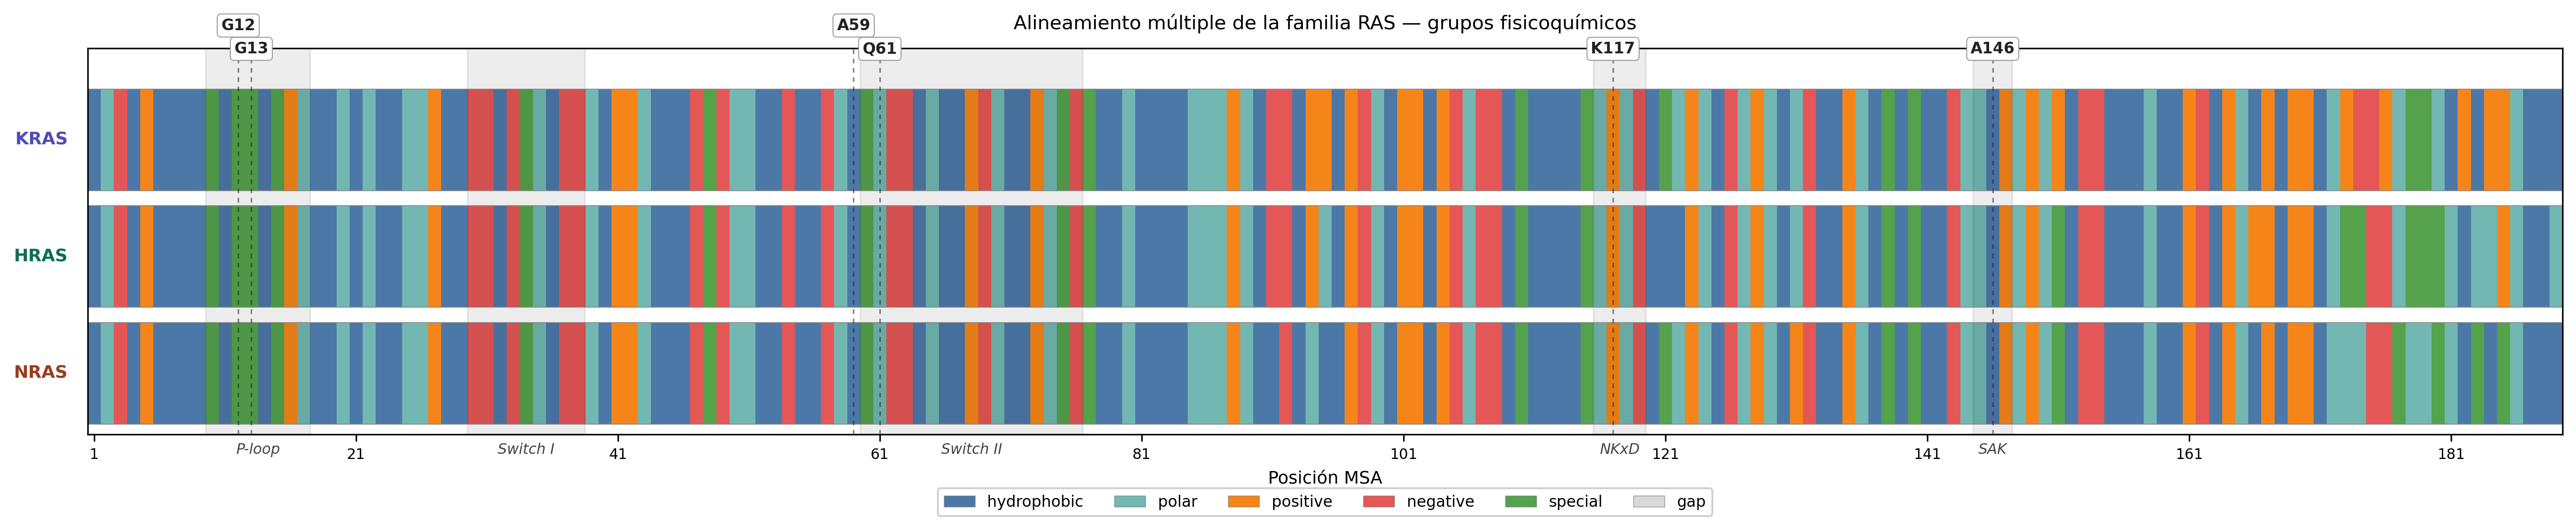

In [19]:
# ============================================================
# CHUNK 10.1: Generar y guardar la figura del MSA
# ============================================================

# visualize_msa() genera la figura, la guarda en disco y cierra el objeto de Matplotlib.
output_fig_path = visualize_msa(
    msa,              # Objeto MultipleSeqAlignment con el alineamiento
    position_map,     # DataFrame con el mapa posicional para localizar regiones
    FIGURE_MSA_PATH   # Ruta de salida (figures/02_msa_overview.png)
)

print(f"[OK] Figura guardada en: {output_fig_path}")
print(f"  Tamano del fichero: {output_fig_path.stat().st_size:,} bytes")


# IPython.display.Image permite mostrar una imagen desde disco directamente en el notebook.
from IPython.display import Image, display

display(Image(filename=str(output_fig_path), width=1200))

---
## Sección 11: Identificación de posiciones recurrentemente mutadas

Una posicion se considera **recurrentemente mutada** si aparece mutada en al menos `min_members` isoformas con un mínimo de `min_samples` muestras tumorales en cada una. Este criterio biológico refleja la **presión selectiva convergente**:

> Si tres genes distintos (KRAS, HRAS, NRAS) adquieren mutaciones en la misma posicion estructural en tumores independientes de diferentes pacientes, esa posicion tiene **relevancia funcional crítica** y probablemente forme parte del sitio activo o de una interfaz proteína-proteína.

Los umbrales de la configuración del proyecto son:
- `recurrent_min_members`: 2
- `recurrent_min_samples_per_member`: 10

Se espera que los hotspots **G12, G13 y Q61** aparezcan en los primeros puestos, dado que acumulan el mayor numero de muestras mutadas en la base de datos COSMIC.

In [20]:
# ============================================================
# CHUNK 11.1: Encontrar posiciones recurrentemente mutadas
# ============================================================

recurrent = find_recurrent_positions(
    curated,       # DataFrame de mutaciones curadas con columnas: gene, position, sample_count, hgvs_p
    position_map,  # Mapa posicional del MSA
    min_members=MIN_MEMBERS,  # Mínimo de isoformas mutadas
    min_samples=MIN_SAMPLES,  # Mínimo de muestras por isoforma
)

print(f"[OK] Análisis de posiciones recurrentes completado.")
print(f"  Parámetros usados:")
print(f"    min_members  : {MIN_MEMBERS} (min. isoformas mutadas por posición)")
print(f"    min_samples  : {MIN_SAMPLES} (min. muestras por isoforma)")
print()
print(f"  Posiciones recurrentes encontradas: {len(recurrent)}")

if recurrent.empty:
    print("  [WARN] No se encontraron posiciones recurrentes con los umbrales actuales.")
    print("  Considera reducir min_members o min_samples en configs/config.yaml.")

[OK] Análisis de posiciones recurrentes completado.
  Parámetros usados:
    min_members  : 2 (min. isoformas mutadas por posición)
    min_samples  : 10 (min. muestras por isoforma)

  Posiciones recurrentes encontradas: 6


---
## Sección 12: Guardar las posiciones recurrentes en formato CSV

El fichero `data/processed/recurrent_positions.csv` contiene las posiciones recurrentemente mutadas con todas sus coordenadas (posición en el MSA, posición en cada isoforma, número de muestras, mutaciones más frecuentes). Este fichero será el punto de partida para el análisis estructural.

In [21]:
# ============================================================
# CHUNK 12.1: Guardar las posiciones recurrentes en CSV
# ============================================================

# to_csv() escribe el DataFrame de posiciones recurrentes en disco.
recurrent.to_csv(RECURRENT_PATH, index=False)

print(f"[OK] Posiciones recurrentes guardadas en: {RECURRENT_PATH}")
print(f"  Filas escritas: {len(recurrent)}")
if RECURRENT_PATH.exists():
    print(f"  Tamano del fichero: {RECURRENT_PATH.stat().st_size:,} bytes")

[OK] Posiciones recurrentes guardadas en: /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/recurrent_positions.csv
  Filas escritas: 6
  Tamano del fichero: 494 bytes


---
## Sección 13: Tabla resumen de posiciones recurrentes

La tabla siguiente muestra todas las posiciones recurrentemente mutadas con sus coordenadas en cada isoforma RAS. Las columnas mas importantes son:

- `msa_position`: columna del alineamiento (referencia universal para comparar entre isoformas).
- `kras_pos`, `hras_pos`, `nras_pos`: posicion 1-based en cada isoforma (puede ser `NaN` si hay gap).
- `n_members_mutated`: cuantas isoformas tienen mutaciones en esta posición con frecuencia suficiente.
- `total_samples`: suma de muestras tumorales en las tres isoformas.
- `top_mutations`: la mutación más frecuente de cada isoforma en esta posición.

Se espera que G12, G13 y Q61 encabecen la tabla, dado que concentran la mayoría de los casos de cáncer RAS-mutado en COSMIC. Estos tres hotspots afectan directamente al mecanismo de hidrólisis del GTP y están presentes en las tres isoformas porque la presión selectiva del cáncer los favorece repetidamente de forma independiente.

In [22]:
# ============================================================
# CHUNK 13.1: Mostrar la tabla de posiciones recurrentes
# ============================================================

if recurrent.empty:
    # Si no hay posiciones recurrentes, avisar al usuario con instrucciones claras.
    print("[WARN] No se encontraron posiciones recurrentes.")
    print("  Posibles causas:")
    print("  1. El dataset curado no tiene suficientes mutaciones (comprueba cosmic_curated.csv).")
    print("  2. Los umbrales min_members o min_samples son demasiado altos.")
    print("  3. Las columnas del dataset curado no tienen los nombres esperados.")
else:
    print(f"Tabla de posiciones recurrentemente mutadas ({len(recurrent)} posiciones):")
    print("Ordenadas por total de muestras tumorales (descendente)\n")

    # Mostrar la tabla completa con todas las posiciones recurrentes.
    display(recurrent.style.hide(axis=0))

Tabla de posiciones recurrentemente mutadas (6 posiciones):
Ordenadas por total de muestras tumorales (descendente)



msa_position,kras_pos,hras_pos,nras_pos,n_members_mutated,total_samples,kras_samples,hras_samples,nras_samples,top_mutations
12,12,12,12,3,12487,11564,195,728,KRAS:p.G12D|HRAS:p.G12S|NRAS:p.G12D
13,13,13,13,3,2604,1917,323,364,KRAS:p.G13D|HRAS:p.G13R|NRAS:p.G13D
61,61,61,61,3,2424,542,365,1517,KRAS:p.Q61H|HRAS:p.Q61R|NRAS:p.Q61R
146,146,146,146,2,361,346,3,12,KRAS:p.A146T|NRAS:p.A146T
117,117,117,117,2,121,104,16,1,KRAS:p.K117N|HRAS:p.K117N
59,59,59,59,2,81,60,9,12,KRAS:p.A59T|NRAS:p.A59T


In [23]:
# ============================================================
# CHUNK 13.2: Análisis detallado de los hotspots principales
# ============================================================

if not recurrent.empty:
    # Mostrar el detalle de las 6 posiciones más frecuentes.
    print("Top 6 posiciones por total de muestras tumorales:")
    print("-" * 130)
    top6 = recurrent.head(6)
    for _, row in top6.iterrows():
        # .iterrows() devuelve pares (indice, Serie) para cada fila del DataFrame.
        # row es una Serie donde cada campo es accesible por nombre.
        print(f"  Posición MSA {int(row['msa_position']):3d} | "
              f"KRAS:{int(row['kras_pos']) if pd.notna(row['kras_pos']) else 'N/A':>3} | "
              f"HRAS:{int(row['hras_pos']) if pd.notna(row['hras_pos']) else 'N/A':>3} | "
              f"NRAS:{int(row['nras_pos']) if pd.notna(row['nras_pos']) else 'N/A':>3} | "
              f"Total muestras: {int(row['total_samples']):>6,} | "
              f"Mutaciones: {row['top_mutations']}")
        
    print("-" * 130)

Top 6 posiciones por total de muestras tumorales:
----------------------------------------------------------------------------------------------------------------------------------
  Posición MSA  12 | KRAS: 12 | HRAS: 12 | NRAS: 12 | Total muestras: 12,487 | Mutaciones: KRAS:p.G12D|HRAS:p.G12S|NRAS:p.G12D
  Posición MSA  13 | KRAS: 13 | HRAS: 13 | NRAS: 13 | Total muestras:  2,604 | Mutaciones: KRAS:p.G13D|HRAS:p.G13R|NRAS:p.G13D
  Posición MSA  61 | KRAS: 61 | HRAS: 61 | NRAS: 61 | Total muestras:  2,424 | Mutaciones: KRAS:p.Q61H|HRAS:p.Q61R|NRAS:p.Q61R
  Posición MSA 146 | KRAS:146 | HRAS:146 | NRAS:146 | Total muestras:    361 | Mutaciones: KRAS:p.A146T|NRAS:p.A146T
  Posición MSA 117 | KRAS:117 | HRAS:117 | NRAS:117 | Total muestras:    121 | Mutaciones: KRAS:p.K117N|HRAS:p.K117N
  Posición MSA  59 | KRAS: 59 | HRAS: 59 | NRAS: 59 | Total muestras:     81 | Mutaciones: KRAS:p.A59T|NRAS:p.A59T
-----------------------------------------------------------------------------------------

---
## Resumen del Hito 2

Este notebook ha completado el **Hito 2** del TFM con los siguientes resultados:

### Ficheros generados

| Fichero | Descripcion |
|---------|-------------|
| `data/processed/msa_ras.fasta` | Alineamiento multiple de KRAS, HRAS y NRAS en formato FASTA |
| `data/processed/position_map.csv` | Mapa de equivalencias posicion-a-posicion entre las tres isoformas |
| `data/processed/recurrent_positions.csv` | Posiciones recurrentemente mutadas en 2 o mas isoformas |
| `figures/02_msa_overview.png` | Visualizacion coloreada del MSA con regiones funcionales |


In [24]:
# ============================================================
# CHUNK FINAL: Resumen de ficheros generados
# ============================================================

# Mostrar un resumen de todos los ficheros generados en este notebook,
# con sus rutas absolutas y tamanos para facilitar la verificacion.
print("Ficheros generados por el Hito 2:")
print("=" * 65)

# Lista de tuplas (descripcion, ruta) de los ficheros de salida
output_files = [
    ("MSA en formato FASTA",          MSA_OUTPUT_PATH),
    ("Mapa posicional CSV",            POSITION_MAP_PATH),
    ("Posiciones recurrentes CSV",     RECURRENT_PATH),
    ("Figura del MSA (PNG)",           FIGURE_MSA_PATH),
]

for description, path in output_files:
    # Comprobar si el fichero existe y obtener su tamano
    if path.exists():
        size_kb = path.stat().st_size / 1024  # Convertir bytes a kilobytes
        print(f"  [OK] {description:<30} {size_kb:6.1f} KB")
        print(f"       {path}")
    else:
        print(f"  [FAIL] {description:<30} NO ENCONTRADO")
        print(f"         {path}")
    print()

print("[OK] Hito 2 completado exitosamente.")

Ficheros generados por el Hito 2:
  [OK] MSA en formato FASTA              0.6 KB
       /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/msa_ras.fasta

  [OK] Mapa posicional CSV               4.7 KB
       /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/position_map.csv

  [OK] Posiciones recurrentes CSV        0.5 KB
       /Users/rachi/Desktop/TFM/tfm_ras_mutations/data/processed/recurrent_positions.csv

  [OK] Figura del MSA (PNG)            117.9 KB
       /Users/rachi/Desktop/TFM/tfm_ras_mutations/figures/02_msa_overview.png

[OK] Hito 2 completado exitosamente.
